## Architecture Overview:
The architecture consists of three main components, a visual backbone, a tabular encoder, and a cross-attention fusion module. An input image is processed by a Swin Transformer to produce a sequence of visual tokens representing different image regions.Tabular data is encoded using an MLP and projected into the same embedding space as the visual tokens. In the cross-attention module, the tabular representation serves as the Query (Q), while the visual tokens act as both Keys (K) and Values (V). This allows the tabular query to attend over image regions, computing attention weights that determine which visual features are most relevant. The weighted combination of Values produces a fused representation that captures modality interactions. This representation is normalized and passed through a fully connected prediction head to produce the final scalar output.

[Only image resolution and augmentation is changed to smaller and light]

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [4]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp13_swin_cross_attn_mse_loss_lightAugAndRes")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp13_cross_attn"]   # define in config
cfg["name"] = "exp13_swin_cross_attn_mse_loss_lightAugAndRes"
cfg["loss"] = "mse"  #
cfg["aug"] = "lite"
cfg["res"] = 256

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="cross_attn_swin",    
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    freeze_backbone=False,              
    # cross-attention specific
    cross_attn_num_heads=8,
    cross_attn_query_mode="tab_queries_image",  #Q->tabular_embed, K&V = visual_tokens or "image_queries_tab"-> Q=visual_tokens, K&V = tabular_embed
    cross_attn_head_hidden=256,
    cross_attn_dropout=0.1,
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp13_swin_cross_attn_mse_loss_lightAugAndRes: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=24.7984 | ValRMSE: 21.1705
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=19.4393 | ValRMSE: 18.6328
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=17.0193 | ValRMSE: 18.6603
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=14.4387 | ValRMSE: 18.4024
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=12.0419 | ValRMSE: 18.2557
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=10.1492 | ValRMSE: 18.3039
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=8.5776 | ValRMSE: 18.3509
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=7.3845 | ValRMSE: 18.2716
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=6.6188 | ValRMSE: 18.3772
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=6.2588 | ValRMSE: 18.2815
Early stopping at epoch 10
Fold 1 best RMSE: 18.2557

=== exp13_swin_cross_attn_mse_loss_lightAugAndRes: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=24.1933 | ValRMSE: 20.6456
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=19.5246 | ValRMSE: 18.4131
Epoch 3/10 | Fold 2 | Train[MSE]

In [5]:

import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.2557 (n=1983)
Fold 2 OOF RMSE: 18.0483 (n=1983)
Fold 3 OOF RMSE: 17.3287 (n=1982)
Fold 4 OOF RMSE: 18.0945 (n=1982)
Fold 5 OOF RMSE: 18.2769 (n=1982)


### Train and Validation RMSE Curve

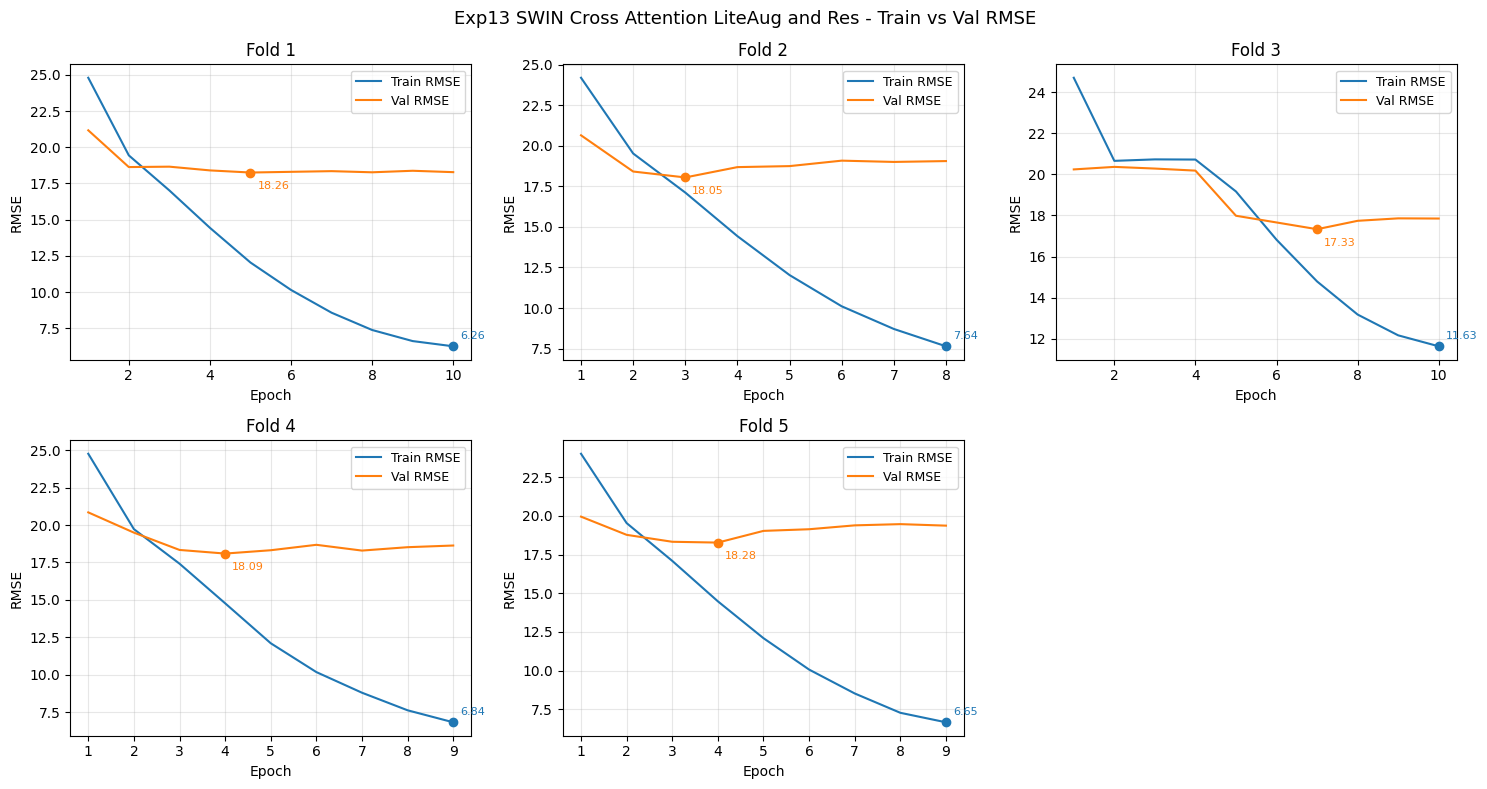

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp13 SWIN Cross Attention LiteAug and Res")